In [2]:
# --- 0) Imports & paths ---
import os, numpy as np, scanpy as sc
from anndata import AnnData
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap
import matplotlib.pyplot as plt

# PyTorch imports
import torch
from torch.utils.data import TensorDataset, DataLoader

# Mixed diffusion imports
from mixed_diffusion.train import train
from mixed_diffusion.models.get_model import get_model
from mixed_diffusion.main_utils import get_device
from mixed_diffusion.config_manager import load_model_config
from mixed_diffusion.model_handler import load_existing_model
from mixed_diffusion.preprocessing.data_transformer import DataTransformer


Loaded low noise training data shape: (1600, 2000)
Loaded low noise training labels shape: (1600,)
Unique labels: [0 1]
Label distribution: [790 810]
Data range: [-34.565, 34.482]
Data mean: 0.004, std: 5.502

=== Computing UMAP for Low Noise Training Data ===


/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


PCA reduced shape: (1600, 15)
UMAP embedding shape: (1600, 2)
PCA explained variance ratio (first 5 components): [0.18237512 0.06551402 0.06398508 0.06180066 0.06148175]
Total variance explained by 15 components: 0.956


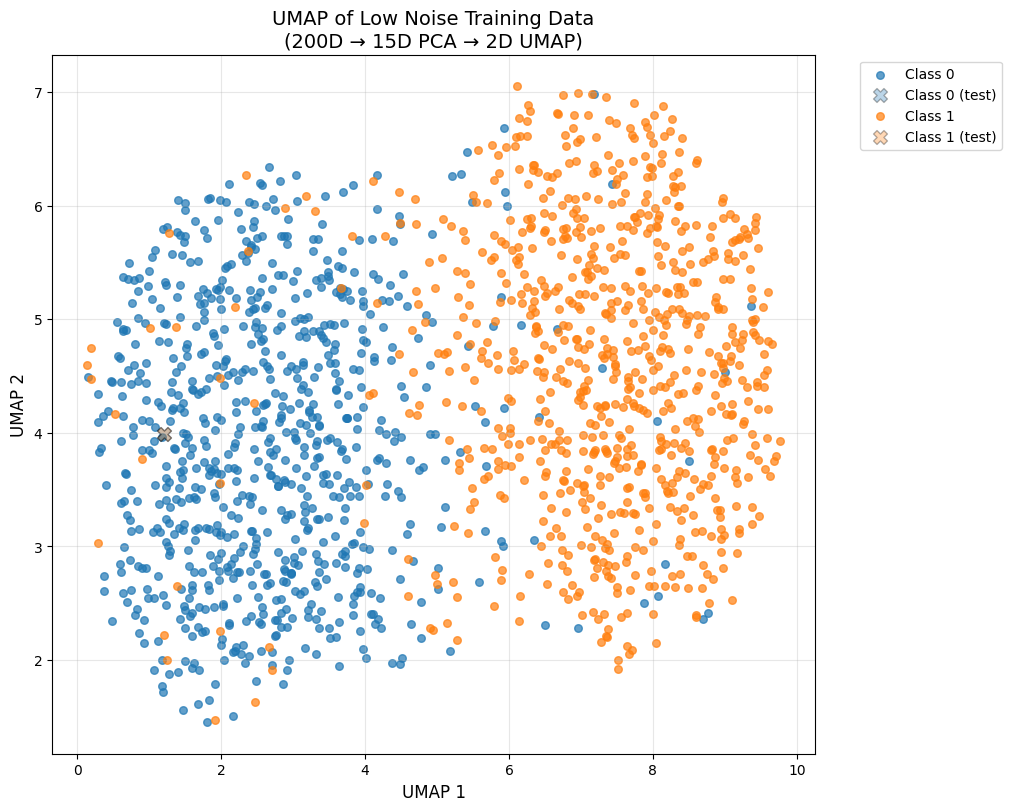


=== Training Data UMAP Summary ===
Data points per class: [790 810]
Total training samples: 1600
UMAP coordinate ranges:
  X: [0.13, 9.77]
  Y: [1.46, 7.05]


In [8]:
# Load the low noise training data
import pandas as pd

# Load the training data and labels
C_train_low_noise = np.load('C_train.npy')
labels_train_low_noise = pd.read_csv('labels_train.csv')
y_train_low_noise = labels_train_low_noise['x'].values

print(f"Loaded low noise training data shape: {C_train_low_noise.shape}")
print(f"Loaded low noise training labels shape: {y_train_low_noise.shape}")
print(f"Unique labels: {np.unique(y_train_low_noise)}")
print(f"Label distribution: {np.bincount(y_train_low_noise)}")
print(f"Data range: [{C_train_low_noise.min():.3f}, {C_train_low_noise.max():.3f}]")
print(f"Data mean: {C_train_low_noise.mean():.3f}, std: {C_train_low_noise.std():.3f}")

# Calculate UMAP for the low noise training data
print("\n=== Computing UMAP for Low Noise Training Data ===")

# First perform PCA to reduce to 15 dimensions (same as in generation notebook)
scaler_train = StandardScaler()
C_train_low_noise_scaled = scaler_train.fit_transform(C_train_low_noise)
pca_train = PCA(n_components=15, random_state=42)
C_train_low_15d = pca_train.fit_transform(C_train_low_noise_scaled)

# Then apply UMAP on the 15D projection
um_train = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=0, metric="cosine").fit(C_train_low_15d)
emb_train = um_train.embedding_

C_test_interpolated = np.load('C_test_interpolated.npy')
emb_test_interpolated = um_train.transform(pca_train.transform(scaler_train.transform(C_test_interpolated)))

print(f"PCA reduced shape: {C_train_low_15d.shape}")
print(f"UMAP embedding shape: {emb_train.shape}")
print(f"PCA explained variance ratio (first 5 components): {pca_train.explained_variance_ratio_[:5]}")
print(f"Total variance explained by 15 components: {pca_train.explained_variance_ratio_.sum():.3f}")

# Plot the UMAP embedding
fig, ax = plt.subplots(1, 1, figsize=(10, 8), constrained_layout=True)

import matplotlib.colors as mcolors
palette = list(mcolors.TABLEAU_COLORS.values())

# Plot each class with different colors
unique_labels = np.unique(y_train_low_noise)
for i, label in enumerate(unique_labels):
    mask = y_train_low_noise == label
    ax.scatter(emb_train[mask, 0], emb_train[mask, 1], 
              s=30, alpha=0.7, 
              c=palette[i % len(palette)],
              label=f'Class {label}')
    ax.scatter(emb_test_interpolated[-1, 0], emb_test_interpolated[-1, 1], 
              s=100, alpha=0.3, 
              c=palette[i % len(palette)],
              edgecolor='k', marker='X', label=f'Class {label} (test)')

ax.set_xlabel("UMAP 1", fontsize=12)
ax.set_ylabel("UMAP 2", fontsize=12)
ax.set_title("UMAP of Low Noise Training Data\n(200D → 15D PCA → 2D UMAP)", fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.show()

print(f"\n=== Training Data UMAP Summary ===")
print(f"Data points per class: {np.bincount(y_train_low_noise)}")
print(f"Total training samples: {len(C_train_low_noise)}")
print(f"UMAP coordinate ranges:")
print(f"  X: [{emb_train[:, 0].min():.2f}, {emb_train[:, 0].max():.2f}]")
print(f"  Y: [{emb_train[:, 1].min():.2f}, {emb_train[:, 1].max():.2f}]")

=== Loading Denoising Results ===
Result folder: gibbs200_rho10.0-10.0_rep500
Loaded denoising results from: /Users/dm954/Documents/code/mixed_diffusion/results/synthetic_d/medium/15pca_interpolated/gibbs200_rho10.0-10.0_rep500/denoising_results.pt
Available keys in results: ['y_train', 'train_labels', 'x_train', 'y_repeated', 'y_noised_repeated', 'y_noised_repeated_labels', 'x_denoised', 'x_denoised_labels', 'x_noised', 'x_true', 'y_test_labels', 'observations', 'observations_labels', 'observation_transform', 'data_config']
Denoised data shape: (5500, 15)
Denoised labels shape: (5500,)
Denoised numeric labels: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.

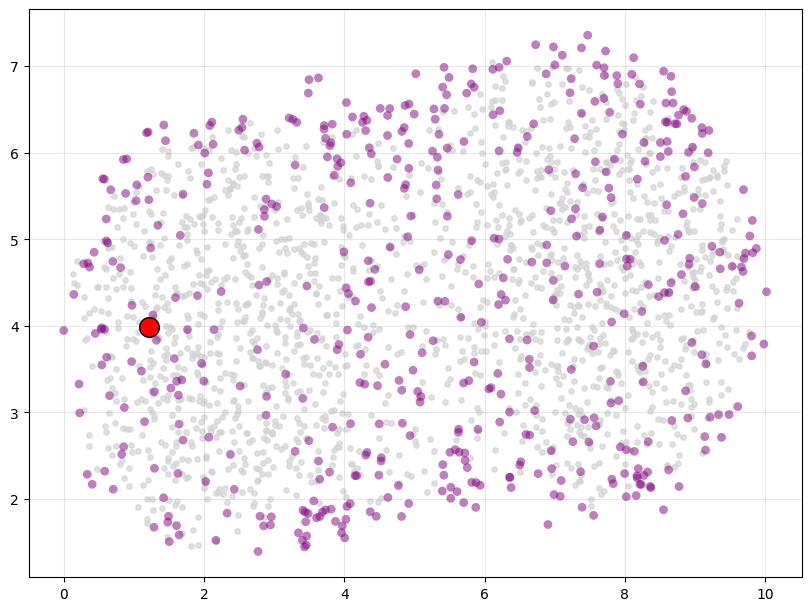

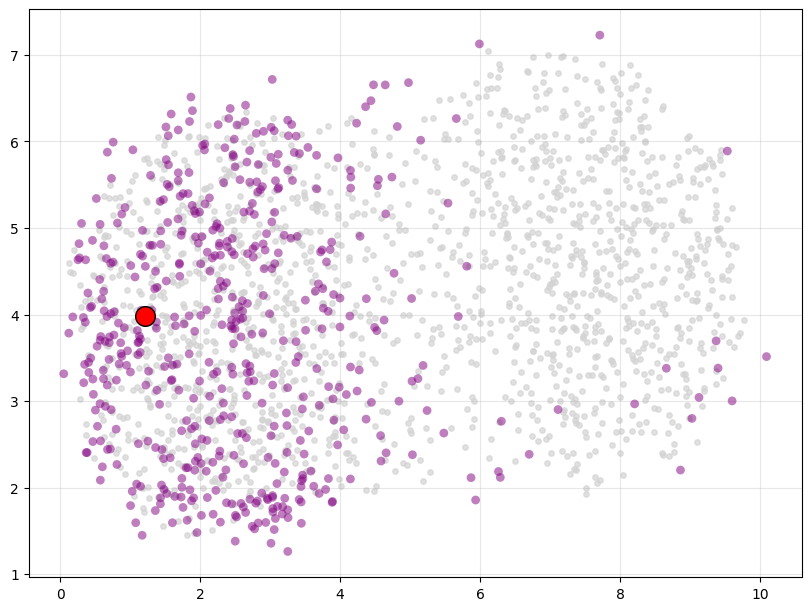

Result folder: gibbs200_rho5.0-5.0_rep500
Loaded denoising results from: /Users/dm954/Documents/code/mixed_diffusion/results/synthetic_d/medium/15pca_interpolated/gibbs200_rho5.0-5.0_rep500/denoising_results.pt
Available keys in results: ['y_train', 'train_labels', 'x_train', 'y_repeated', 'y_noised_repeated', 'y_noised_repeated_labels', 'x_denoised', 'x_denoised_labels', 'x_noised', 'x_true', 'y_test_labels', 'observations', 'observations_labels', 'observation_transform', 'data_config']
Denoised data shape: (5500, 15)
Denoised labels shape: (5500,)
Denoised numeric labels: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np

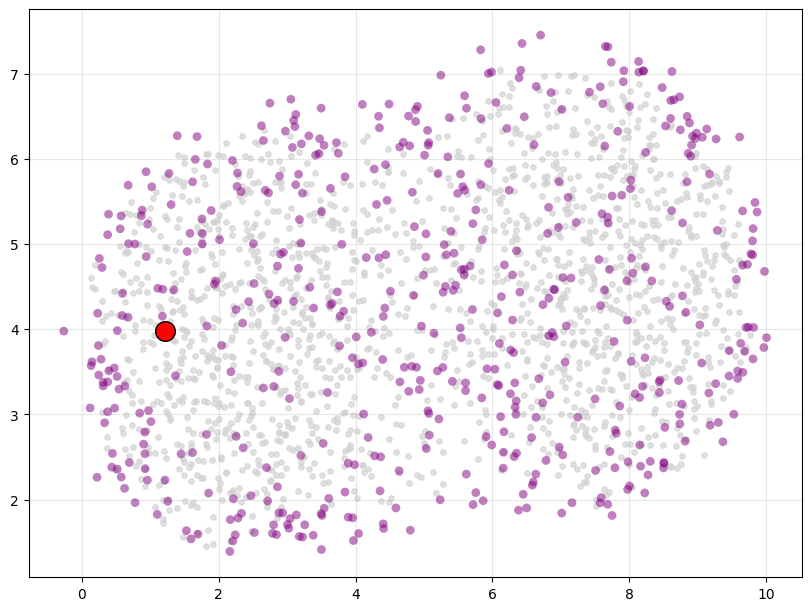

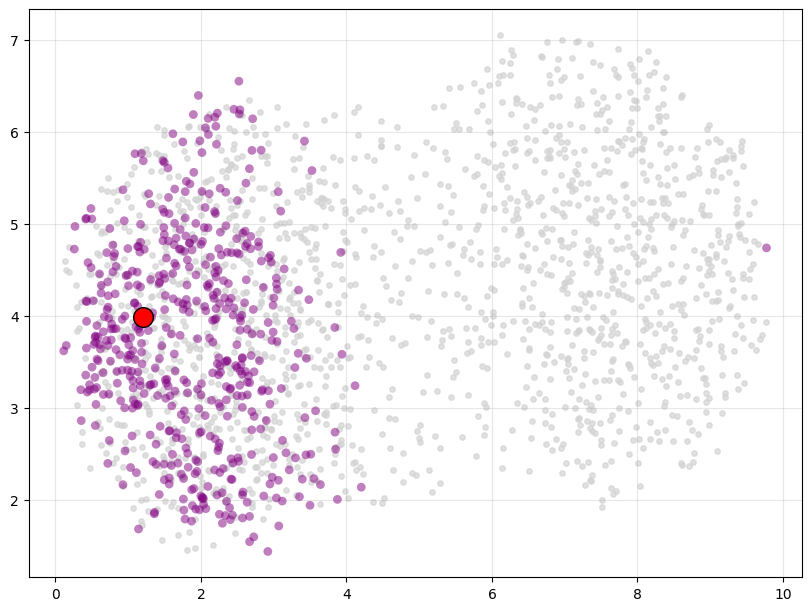

Result folder: gibbs200_rho0.1-0.1_rep500
Loaded denoising results from: /Users/dm954/Documents/code/mixed_diffusion/results/synthetic_d/medium/15pca_interpolated/gibbs200_rho0.1-0.1_rep500/denoising_results.pt
Available keys in results: ['y_train', 'train_labels', 'x_train', 'y_repeated', 'y_noised_repeated', 'y_noised_repeated_labels', 'x_denoised', 'x_denoised_labels', 'x_noised', 'x_true', 'y_test_labels', 'observations', 'observations_labels', 'observation_transform', 'data_config']
Denoised data shape: (5500, 15)
Denoised labels shape: (5500,)
Denoised numeric labels: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np

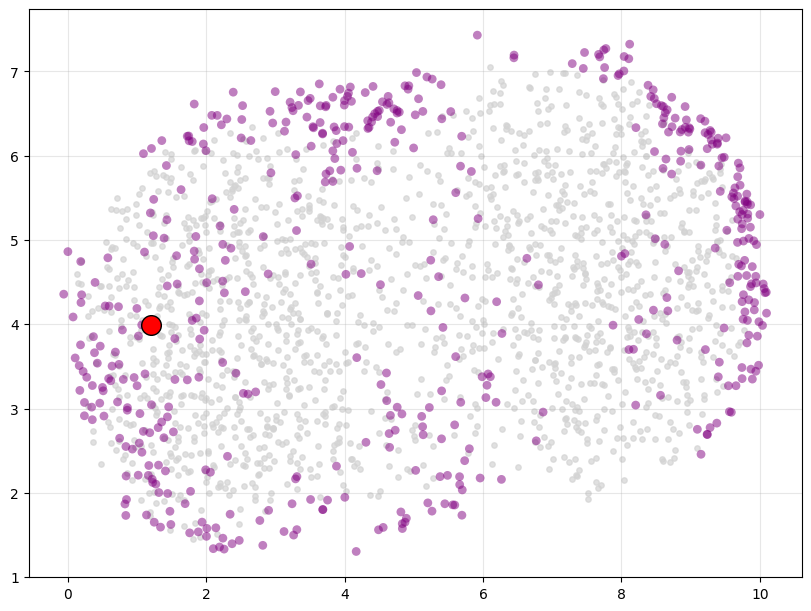

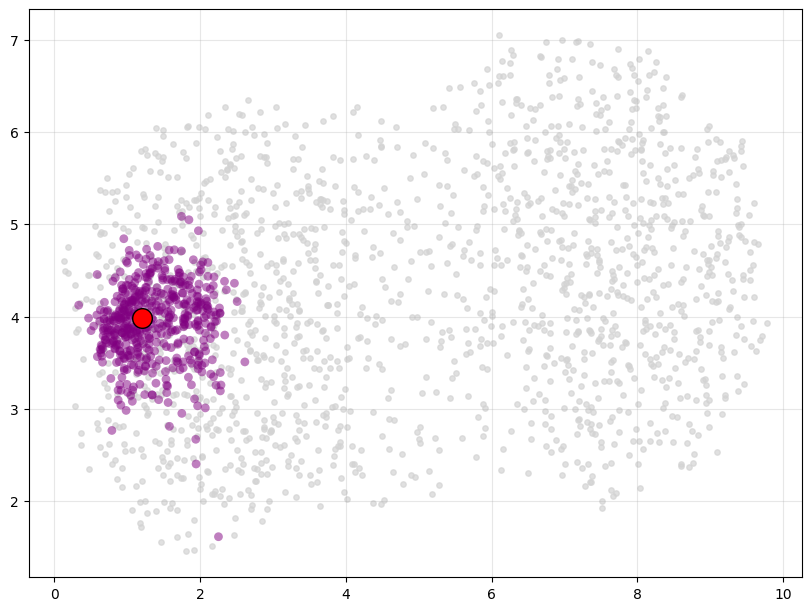

Result folder: gibbs200_rho1.0-1.0_rep500
Loaded denoising results from: /Users/dm954/Documents/code/mixed_diffusion/results/synthetic_d/medium/15pca_interpolated/gibbs200_rho1.0-1.0_rep500/denoising_results.pt
Available keys in results: ['y_train', 'train_labels', 'x_train', 'y_repeated', 'y_noised_repeated', 'y_noised_repeated_labels', 'x_denoised', 'x_denoised_labels', 'x_noised', 'x_true', 'y_test_labels', 'observations', 'observations_labels', 'observation_transform', 'data_config']
Denoised data shape: (5500, 15)
Denoised labels shape: (5500,)
Denoised numeric labels: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np

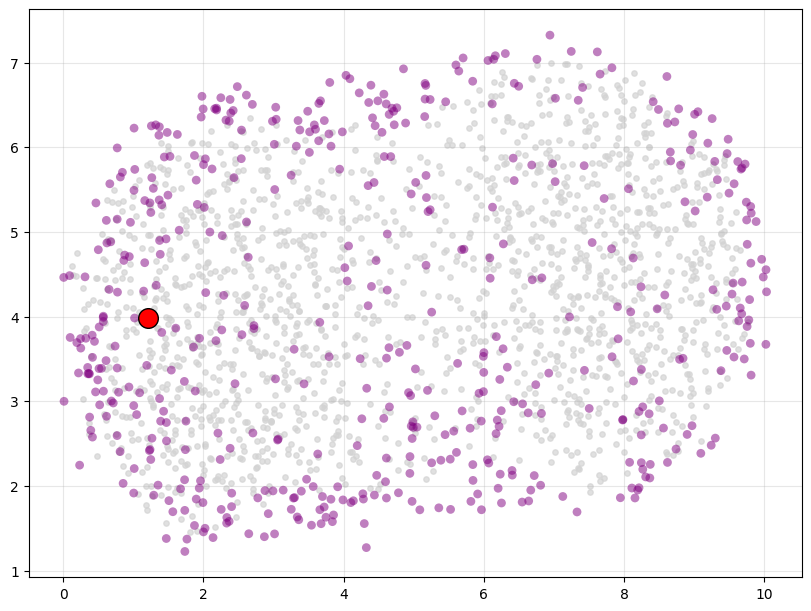

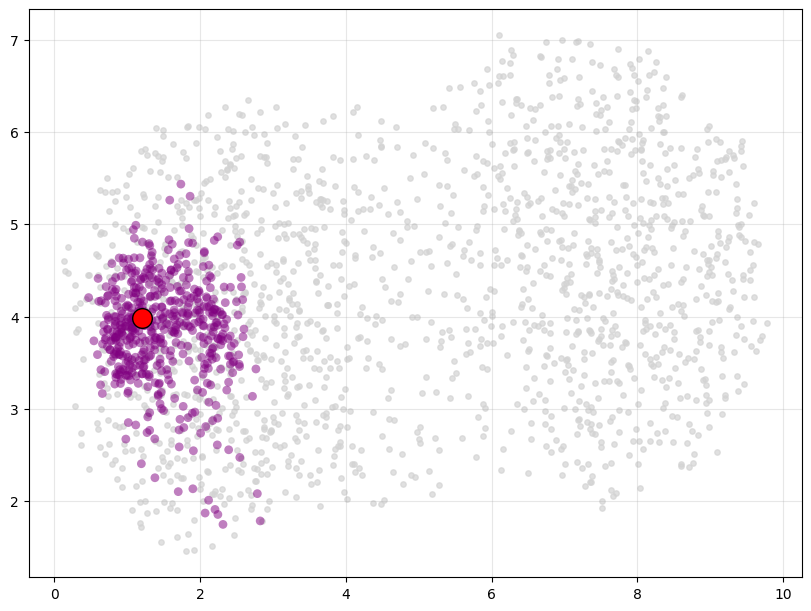

Result folder: gibbs200_rho10.0-5.0_rep500
Loaded denoising results from: /Users/dm954/Documents/code/mixed_diffusion/results/synthetic_d/medium/15pca_interpolated/gibbs200_rho10.0-5.0_rep500/denoising_results.pt
Available keys in results: ['y_train', 'train_labels', 'x_train', 'y_repeated', 'y_noised_repeated', 'y_noised_repeated_labels', 'x_denoised', 'x_denoised_labels', 'x_noised', 'x_true', 'y_test_labels', 'observations', 'observations_labels', 'observation_transform', 'data_config']
Denoised data shape: (5500, 15)
Denoised labels shape: (5500,)
Denoised numeric labels: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), 

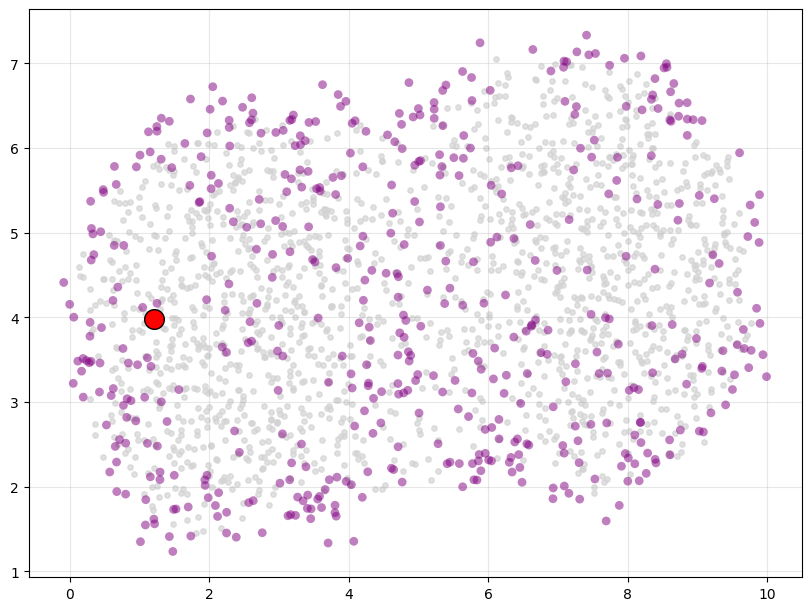

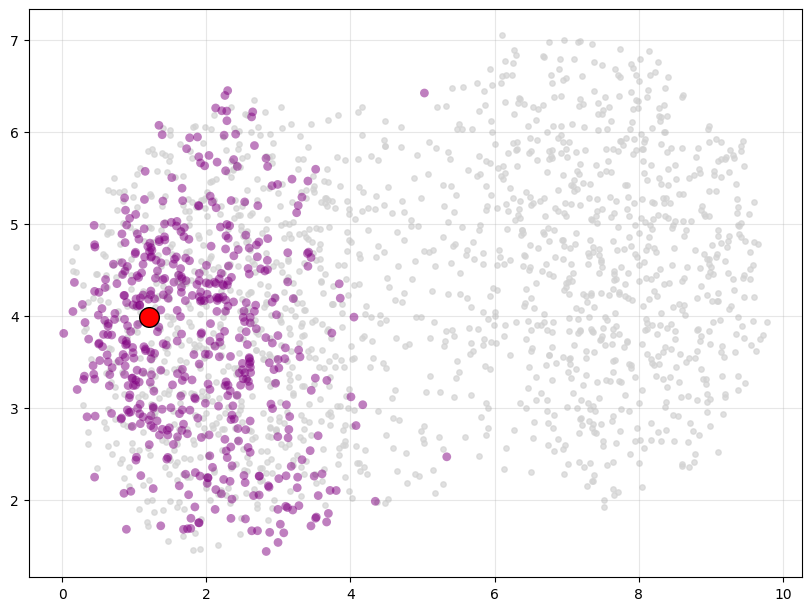

Result folder: gibbs200_rho20.0-20.0_rep500
Loaded denoising results from: /Users/dm954/Documents/code/mixed_diffusion/results/synthetic_d/medium/15pca_interpolated/gibbs200_rho20.0-20.0_rep500/denoising_results.pt
Available keys in results: ['y_train', 'train_labels', 'x_train', 'y_repeated', 'y_noised_repeated', 'y_noised_repeated_labels', 'x_denoised', 'x_denoised_labels', 'x_noised', 'x_true', 'y_test_labels', 'observations', 'observations_labels', 'observation_transform', 'data_config']
Denoised data shape: (5500, 15)
Denoised labels shape: (5500,)
Denoised numeric labels: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2)

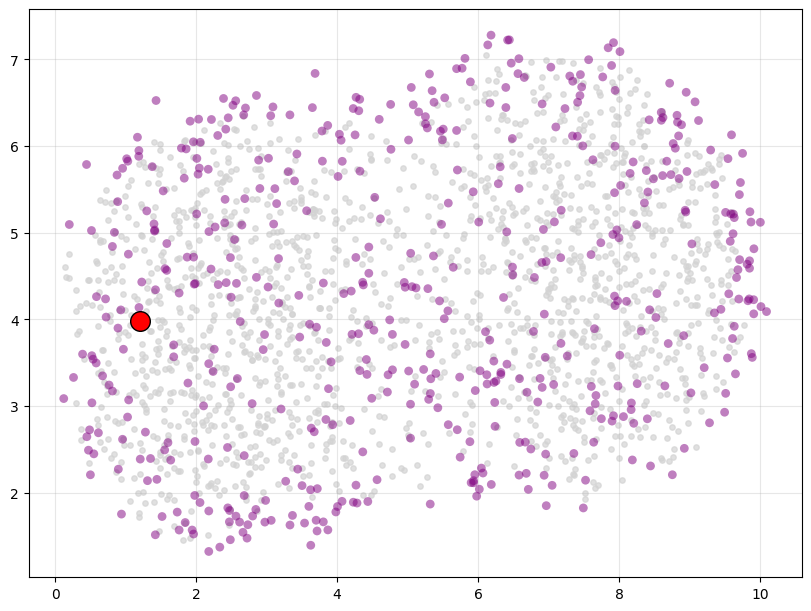

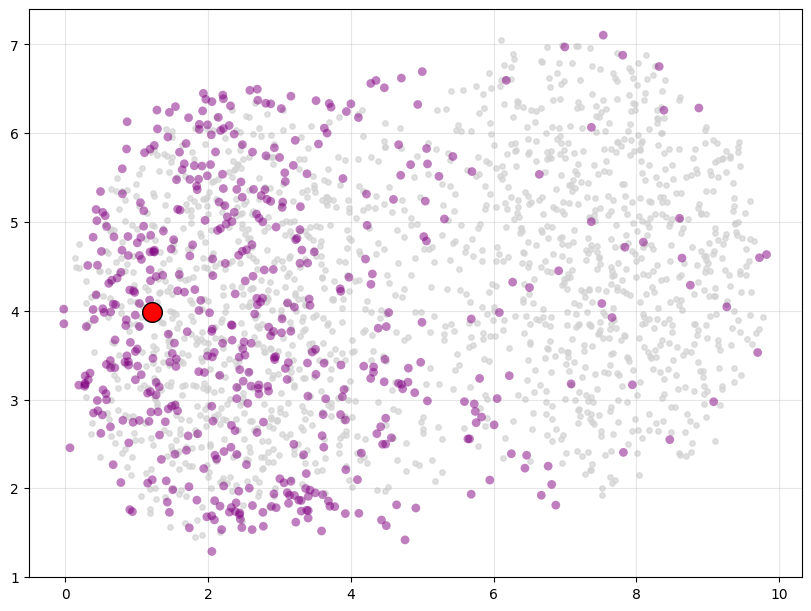

Result folder: gibbs200_rho0.5-0.5_rep500
Loaded denoising results from: /Users/dm954/Documents/code/mixed_diffusion/results/synthetic_d/medium/15pca_interpolated/gibbs200_rho0.5-0.5_rep500/denoising_results.pt
Available keys in results: ['y_train', 'train_labels', 'x_train', 'y_repeated', 'y_noised_repeated', 'y_noised_repeated_labels', 'x_denoised', 'x_denoised_labels', 'x_noised', 'x_true', 'y_test_labels', 'observations', 'observations_labels', 'observation_transform', 'data_config']
Denoised data shape: (5500, 15)
Denoised labels shape: (5500,)
Denoised numeric labels: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np

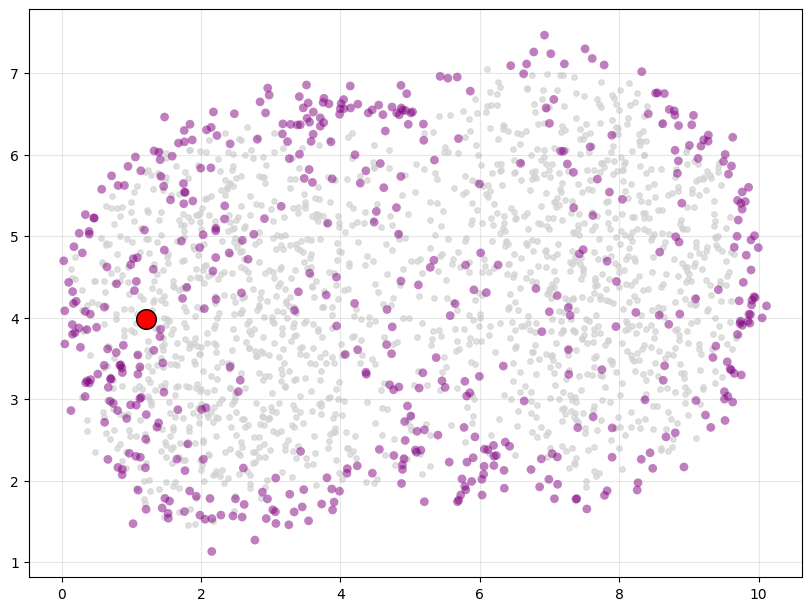

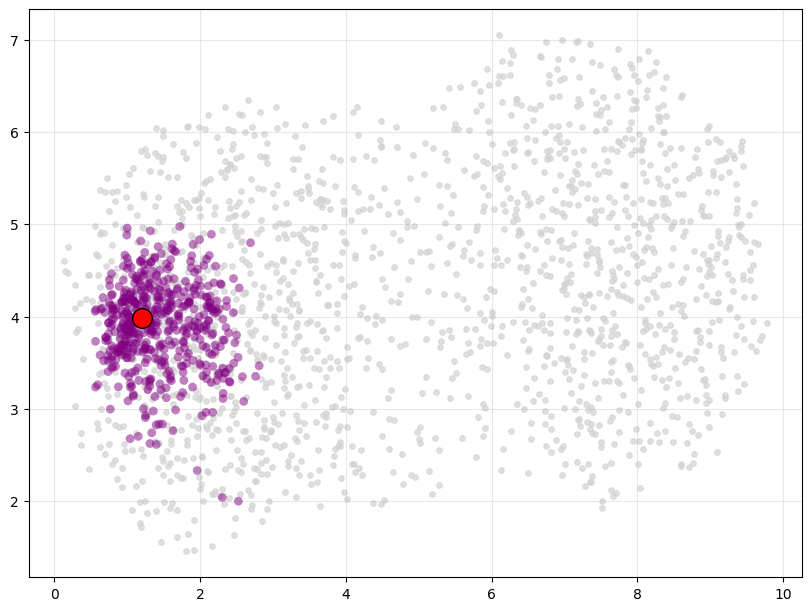

In [15]:
import glob

# Load denoising results and plot x_denoised in UMAP space
print("=== Loading Denoising Results ===")

for results_path in glob.glob("/Users/dm954/Documents/code/mixed_diffusion/results/synthetic_d/medium/15pca_interpolated/gibbs200_*/denoising_results.pt"):
    denoising_results = torch.load(results_path, map_location='cpu', weights_only=False)
    # extract folder name containing the results file
    folder_path = os.path.dirname(results_path)
    folder_name = os.path.basename(folder_path)
    print(f"Result folder: {folder_name}")

    print(f"Loaded denoising results from: {results_path}")
    print(f"Available keys in results: {list(denoising_results.keys())}")

    # Extract the denoised data and its labels
    x_denoised = denoising_results['x_denoised']
    x_denoised_labels = denoising_results['x_denoised_labels']
    data_config = denoising_results['data_config']
    label_encoder = data_config['label_encoder']

    if hasattr(x_denoised, 'cpu'):
        x_denoised = x_denoised.cpu().numpy()
    if hasattr(x_denoised_labels, 'cpu'):
        x_denoised_labels = x_denoised_labels.cpu().numpy()

    print(f"Denoised data shape: {x_denoised.shape}")
    print(f"Denoised labels shape: {x_denoised_labels.shape}")
    print(f"Denoised numeric labels: {list(x_denoised_labels)}")

    # Transform numeric labels to string labels using label encoder
    # The label_encoder maps string_label -> numeric_value, so we need to reverse it
    reverse_label_encoder = {v: k for k, v in label_encoder.items()}
    x_denoised_labels_str = [reverse_label_encoder[int(label)] for label in x_denoised_labels]

    print(f"Denoised string labels: {x_denoised_labels_str}")
    print(f"Available label encodings: {label_encoder}")
    print(f"Denoised data range: [{x_denoised.min():.3f}, {x_denoised.max():.3f}]")
    print(f"Denoised data mean: {x_denoised.mean():.3f}, std: {x_denoised.std():.3f}")

    # Transform denoised data using UMAP fitted on training data (skip PCA as already transformed)
    print("\n=== Transforming Denoised Data Using Training UMAP ===")

    # x_denoised is already PCA transformed, so directly apply UMAP
    print(f"Denoised data is already PCA transformed with shape: {x_denoised.shape}")

    # Transform using the UMAP fitted on training data
    emb_denoised = um_train.transform(x_denoised)

    print(f"Denoised data UMAP embedding shape: {emb_denoised.shape}")


    # Filter for only the interpolation point (remove cluster means)
    target_labels = ['cluster_0_100pct', 'cluster_1_100pct', 'interp_0_40pct_1_60pct']
    # target_labels = ['0', '1']

    # Plot interpolation test points (original input) - only interpolation point
    # Define target labels to visualize
    target_labels = ['alpha_50', 'alpha_100']

    # Color mapping for input points
    # Create dynamic color mapping based on target_labels
    input_colors = {}
    color_options = ['darkred']
    for i, label in enumerate(target_labels):
        input_colors[label] = color_options[i % len(color_options)]

    for idx, target_label in enumerate(target_labels):
        # Create a fresh figure for this target label so each label gets its own plot
        fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
        
        # Plot training data in grey as background
        ax.scatter(emb_train[:, 0], emb_train[:, 1], 
                s=15, alpha=0.7, 
                c='lightgrey',
                label='Training data',
                zorder=1)
        ax.scatter(emb_test_interpolated[-1, 0], emb_test_interpolated[-1, 1], s=200, alpha=1, 
                  c='red', edgecolor='k', zorder=100)
        
        # Find and plot the input point for this target label
        # input_plotted = False
        # for i, label in enumerate(y_test_interpolation):
        #     if label == target_label:
        #         ax.scatter(emb_test_interpolation[i, 0], emb_test_interpolation[i, 1], 
        #                   s=250, alpha=0.9, 
        #                   c=input_colors[target_label],
        #                   edgecolors='black',
        #                   linewidths=3,
        #                   marker='o',
        #                   label=f'Input: {target_label}',
        #                   zorder=4)
        #         input_plotted = True
        #         break
        
        # Plot denoised points for this target label only
        denoised_count = 0
        for i, (predicted_label_num, predicted_label_str) in enumerate(zip(x_denoised_labels, x_denoised_labels_str)):
            if predicted_label_str == target_label:
                # Use color based on predicted label
                color = palette[int(predicted_label_num) % len(palette)]
                
                ax.scatter(emb_denoised[i, 0], emb_denoised[i, 1], 
                        s=40, alpha=0.5,  # Translucent circles
                        c="purple",
                        edgecolors='none',  # No borders
                        marker='o',  # Circles
                        label=f'Denoised samples' if denoised_count == 0 else "",
                        zorder=3)
                denoised_count += 1
        
        # Customize each subplot
        # ax.set_xlabel("UMAP 1", fontsize=12)
        # ax.set_ylabel("UMAP 2", fontsize=12)
        # ax.set_title(f"{target_label}\n({denoised_count} denoised samples)", fontsize=12, pad=15)
        ax.grid(True, alpha=0.3)
        # ax.legend(fontsize=10, loc='upper right')
        
        plt.savefig(f"../../figures/{folder_name}_{idx}.pdf")
                    

    plt.show()